In [ ]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D,Flatten, Dense

In [ ]:
!mkdir -p ~/.kaggle && echo KGAT_69400e5118787c91b55cdf8ad67045f8 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
!kaggle datasets download -d kunalgupta2616/dog-vs-cat-images-data

Dataset URL: https://www.kaggle.com/datasets/kunalgupta2616/dog-vs-cat-images-data
License(s): GPL-2.0
100% 991M/991M [00:06<00:00, 152MB/s]



In [ ]:
import zipfile
zip_ref=zipfile.ZipFile('/content/dog-vs-cat-images-data.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

##**Two method to load data:**
##1. From Scratch
##2. Used Generator

In [ ]:
#loop on the images folder, convert into numpy array and assign the labels

mydir='C:\user\folder\train   '
data=[]
categories=['cats', 'dogs']
for i in categories:
      folder_path = os.path.join(mydir,i)
      if i=='cats':
         label=0
      else:
        label=1
      for j in os.listdir(folder_path): #loop on the images folder
        img_path=os.path.join(folder_path, j) #get the image location
        img=cv2.imread(img_path) # convert image to numpy array
        img=cv2.resize(img, (150,150))
        data.append([img,label])
#shuffle the data
random.shuffle(data)

# Assign input & output values
X=[]
Y=[]
for i in data:
  X.appedn(i[0])
  Y.appedn(i[1])
#convert into array
y=np.array(Y)
x=np.array(X)
#normalize(0-1)
x=x/255

In [ ]:
#generators
train_ds= keras.utils.image_dataset_from_directory(
    directory='/content/dogcat/train',
    labels = 'inferred',
    label_mode = 'int',
    image_size=(256, 256)
)

val_ds=keras.utils.image_dataset_from_directory(
    directory='/content/dogcat/test1' ,
    labels = 'inferred' ,
    label_mode = 'int' ,
    image_size=(256,256)
)

Found 25000 files belonging to 2 classes.
Found 12500 files belonging to 1 classes.


In [ ]:
#Normalize
def process(image,label):
  image=tf.cast(image/255, tf.float32)
  return image, label

train_ds=train_ds.map(process)
val_ds=val_ds.map(process)

In [ ]:
#Create CNN model
model=Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid' ))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid' ))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid' ))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
#data from scratch coding
history=model.fit(x,y, epochs=10, validation_data=0.1)

#data from generator
history=model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 92ms/step - accuracy: 0.9919 - loss: 0.0260 - val_accuracy: 0.5108 - val_loss: 5.6762
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 86ms/step - accuracy: 0.9921 - loss: 0.0299 - val_accuracy: 0.5551 - val_loss: 4.2229
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 91ms/step - accuracy: 0.9922 - loss: 0.0267 - val_accuracy: 0.4748 - val_loss: 5.2995
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 92ms/step - accuracy: 0.9921 - loss: 0.0250 - val_accuracy: 0.5670 - val_loss: 4.4719
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 91ms/step - accuracy: 0.9949 - loss: 0.0176 - val_accuracy: 0.4980 - val_loss: 6.0453
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.9935 - loss: 0.0213 - val_accuracy: 0.4854 - val_loss: 6.5205
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.9938 - loss: 0.0208 - val_accuracy: 0.5221 - val_loss: 5.3254
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.9950 - loss: 0.0188 - 

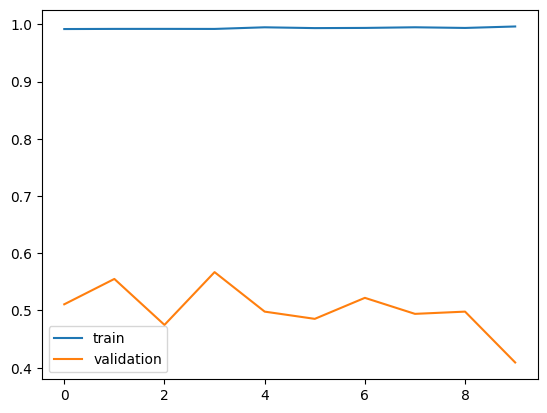

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()

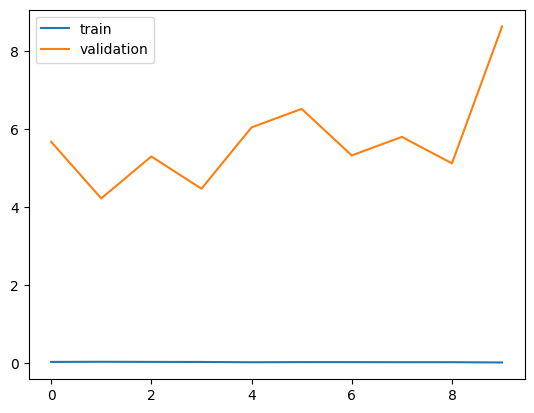

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.legend()

In [ ]:
!pip install opencv-python

In [ ]:
import cv2

array([[[ 42,  36,  34],
        [ 42,  36,  34],
        [ 42,  36,  34],
        ...,
        [ 42,  36,  34],
        [ 42,  36,  34],
        [ 42,  36,  34]],

       [[ 42,  36,  34],
        [ 42,  36,  34],
        [ 42,  36,  34],
        ...,
        [ 42,  36,  34],
        [ 42,  36,  34],
        [ 42,  36,  34]],

       [[ 42,  36,  34],
        [ 42,  36,  34],
        [ 42,  36,  34],
        ...,
        [ 42,  36,  34],
        [ 42,  36,  34],
        [ 42,  36,  34]],

       ...,

       [[ 55,  97, 109],
        [ 52,  93, 104],
        [ 50,  90, 102],
        ...,
        [ 95, 181, 202],
        [ 98, 182, 204],
        [101, 183, 206]],

       [[ 55,  97, 109],
        [ 52,  93, 104],
        [ 50,  90, 102],
        ...,
        [101, 186, 207],
        [103, 185, 207],
        [104, 185, 208]],

       [[ 55,  97, 110],
        [ 52,  93, 106],
        [ 50,  90, 104],
        ...,
        [106, 185, 206],
        [104, 184, 206],
        [104, 183, 206]]], dtype=uint8)
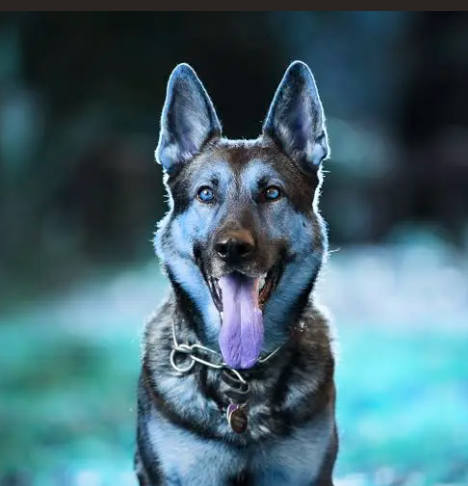

In [ ]:
img=cv2.imread('/content/dog.PNG')
img

In [ ]:
img.shape

(486, 468, 3)

array([[[ 42,  36,  34],
        [ 42,  36,  34],
        [ 42,  36,  34],
        ...,
        [ 42,  36,  34],
        [ 42,  36,  34],
        [ 42,  36,  34]],

       [[ 42,  36,  34],
        [ 42,  36,  34],
        [ 42,  36,  34],
        ...,
        [ 42,  36,  34],
        [ 42,  36,  34],
        [ 42,  36,  34]],

       [[ 42,  36,  34],
        [ 42,  36,  34],
        [ 42,  36,  34],
        ...,
        [ 42,  36,  34],
        [ 42,  36,  34],
        [ 42,  36,  34]],

       ...,

       [[ 52,  95, 107],
        [ 50,  90, 102],
        [ 48,  88,  99],
        ...,
        [ 76, 167, 189],
        [ 79, 169, 190],
        [ 88, 173, 197]],

       [[ 54,  95, 107],
        [ 50,  89, 101],
        [ 47,  86,  98],
        ...,
        [ 90, 178, 199],
        [ 91, 178, 200],
        [ 98, 181, 203]],

       [[ 54,  95, 108],
        [ 50,  89, 102],
        [ 47,  86,  99],
        ...,
        [104, 186, 207],
        [104, 185, 206],
        [104, 184, 207]]], dtype=uint8)
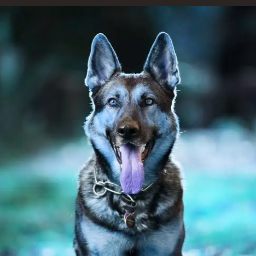

In [ ]:
test_img=cv2.resize(img,(256,256))
test_img

In [ ]:
test_input=test_img.reshape(1,256,256,3)
test_input.shape

(1, 256, 256, 3)

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[1.]], dtype=float32)